In [3]:

import requests
import pandas as pd
import time




API_TARGET = 700

search_terms = [
    "fiction",
    "fantasy",
    "romance",
    "mystery",
    "science fiction",
    "history",
    "biography",
    "children",
    "adventure",
    "classic"
]

api_books = []
seen_titles = set()

for term in search_terms:

    if len(api_books) >= API_TARGET:
        break

    url = "https://openlibrary.org/search.json"

    params = {
        "q": term,
        "limit": 100,
        "fields": "title,author_name,first_publish_year,subject,ratings_average,ratings_count"
    }

    print("API collecting:", term)

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    data = response.json()

    for book in data.get("docs", []):

        title = book.get("title", "").strip()

        if title == "":
            continue

        if title.lower() in seen_titles:
            continue

        seen_titles.add(title.lower())

        authors = ", ".join(book.get("author_name", []))
        subjects = " | ".join(book.get("subject", [])[:10])

        api_books.append({
            "title": title,
            "authors": authors,
            "subjects": subjects,
            "category": term,
            "rating": book.get("ratings_average", ""),
            "ratings_count": book.get("ratings_count", ""),
            "price": "Not Available",
            "year": book.get("first_publish_year", ""),
            "source": "Open Library API"
        })

        if len(api_books) >= API_TARGET:
            break

    print("Collected API books:", len(api_books))
    time.sleep(1)

df_api = pd.DataFrame(api_books)

print("Final API shape:", df_api.shape)
df_api.head()

/Users/pol/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


API collecting: fiction
Collected API books: 99
API collecting: fantasy
Collected API books: 192
API collecting: romance
Collected API books: 290
API collecting: mystery
Collected API books: 389
API collecting: science fiction
Collected API books: 440
API collecting: history
Collected API books: 539
API collecting: biography
Collected API books: 633
API collecting: children
Collected API books: 700
Final API shape: (700, 9)


,title,authors,subjects,category,rating,ratings_count,price,year,source
0,Ficciones,Jorge Luis Borges,Anachronisms | speculative fiction | subjectiv...,fiction,4.342105,38,Not Available,1945,Open Library API
1,Great Sf Heinlein Bxs,Robert A. Heinlein,Hugo Award Winner | award:hugo_award=1962 | aw...,fiction,3.647059,68,Not Available,1980,Open Library API
2,The Science Fiction Hall of Fame -- Volume One,"Robert Silverberg, Robert A. Heinlein, Arthur ...",Science fiction | American Science fiction | E...,fiction,4.5,6,Not Available,1970,Open Library API
3,Wild seed,Octavia E. Butler,Fiction in English | Fiction | Sex role | Wome...,fiction,4.545454,11,Not Available,1980,Open Library API
4,Smoke and Mirrors,"Neil Gaiman, Richard Chizmar, William Peter Bl...","Fantasy | Fiction | Fiction, general | Assassi...",fiction,3.75,16,Not Available,1998,Open Library API


In [4]:
df_api.to_csv("openlibrary_api_books.csv", index=False)

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

BOOKS_PER_CATEGORY = 100

goodreads_lists = {
    "Fantasy": "https://www.goodreads.com/list/show/50.The_Best_Epic_Fantasy_fiction",
    "Romance": "https://www.goodreads.com/list/show/12362.All_Time_Favorite_Romance_Novels",
    "Mystery": "https://www.goodreads.com/list/show/11.Best_Crime_Mystery_Books",
    "Science Fiction": "https://www.goodreads.com/list/show/19341.Best_Science_Fiction",
    "Historical Fiction": "https://www.goodreads.com/list/show/15.Best_Historical_Fiction",
    "Young Adult": "https://www.goodreads.com/list/show/43.Best_Young_Adult_Books",
    "Classics": "https://www.goodreads.com/list/show/449.Must_Read_Classics"
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

scraped_books = []
seen_titles = set()

def get_page_with_retry(url, params, retries=3):
    for attempt in range(retries):
        try:
            response = requests.get(
                url,
                params=params,
                headers=headers,
                timeout=60
            )

            if response.status_code in [403, 429]:
                print("Blocked or too many requests:", response.status_code)
                return None

            response.raise_for_status()
            return response

        except requests.exceptions.ReadTimeout:
            print(f"Timeout. Trying again... {attempt + 1}/{retries}")
            time.sleep(20)

        except requests.exceptions.RequestException as e:
            print("Request error:", e)
            time.sleep(20)

    return None


for category, list_url in goodreads_lists.items():

    category_count = 0
    page = 1

    while category_count < BOOKS_PER_CATEGORY:

        print(f"\nScraping category: {category}, page: {page}")

        response = get_page_with_retry(
            list_url,
            params={"page": page}
        )

        if response is None:
            print("Skipping this category/page.")
            break

        soup = BeautifulSoup(response.text, "html.parser")

        rows = soup.select("tr[itemtype='http://schema.org/Book']")

        print("Books found:", len(rows))

        if len(rows) == 0:
            print("No books found. Moving to next category.")
            break

        for row in rows:
            title_tag = row.select_one("a.bookTitle span")
            title = title_tag.get_text(strip=True) if title_tag else ""

            if title == "":
                continue

            if title.lower() in seen_titles:
                continue

            seen_titles.add(title.lower())

            author_tag = row.select_one("a.authorName span")
            authors = author_tag.get_text(strip=True) if author_tag else ""

            rating_tag = row.select_one("span.minirating")
            rating_text = rating_tag.get_text(" ", strip=True) if rating_tag else ""

            rating = ""
            ratings_count = ""

            if "avg rating" in rating_text:
                rating = rating_text.split("avg rating")[0].strip()

            if "—" in rating_text and "ratings" in rating_text:
                ratings_count = (
                    rating_text
                    .split("—")[-1]
                    .replace("ratings", "")
                    .replace("rating", "")
                    .replace(",", "")
                    .strip()
                )

            scraped_books.append({
                "title": title,
                "authors": authors,
                "subjects": category,
                "category": category,
                "rating": rating,
                "ratings_count": ratings_count,
                "price": "Not Available",
                "year": "",
                "source": "Goodreads Scraping"
            })

            category_count += 1

            if category_count >= BOOKS_PER_CATEGORY:
                break

        print(f"{category} collected:", category_count)
        print("Total collected:", len(scraped_books))

        # Save progress after every page
        temp_df = pd.DataFrame(scraped_books)
        temp_df.to_csv("goodreads_scraped_progress.csv", index=False)

        page += 1
        time.sleep(random.uniform(10, 20))

df_scrap_new = pd.DataFrame(scraped_books)

df_scrap_new.to_csv("goodreads_scraped_books_with_categories.csv", index=False)

print("Final shape:", df_scrap_new.shape)
df_scrap_new["category"].value_counts()


Scraping category: Fantasy, page: 1
Timeout. Trying again... 1/3
Books found: 100
Fantasy collected: 100
Total collected: 100

Scraping category: Romance, page: 1
Books found: 100
Romance collected: 100
Total collected: 200

Scraping category: Mystery, page: 1
Books found: 100
Mystery collected: 99
Total collected: 299

Scraping category: Mystery, page: 2
Books found: 100
Mystery collected: 100
Total collected: 300

Scraping category: Science Fiction, page: 1
Books found: 100
Science Fiction collected: 99
Total collected: 399

Scraping category: Science Fiction, page: 2
Books found: 100
Science Fiction collected: 100
Total collected: 400

Scraping category: Historical Fiction, page: 1
Books found: 100
Historical Fiction collected: 88
Total collected: 488

Scraping category: Historical Fiction, page: 2
Books found: 100
Historical Fiction collected: 100
Total collected: 500

Scraping category: Young Adult, page: 1
Books found: 100
Young Adult collected: 70
Total collected: 570

Scraping

category
Fantasy               100
Romance               100
Mystery               100
Science Fiction       100
Historical Fiction    100
Young Adult           100
Classics              100
Name: count, dtype: int64

In [7]:
import pandas as pd

common_columns = [
    "title",
    "authors",
    "subjects",
    "category",
    "rating",
    "ratings_count",
    "price",
    "year",
    "source"
]

# Make copies
api_df = df_api.copy()
scrap_df = df_scrap_new.copy()

# Make sure all common columns exist
for col in common_columns:
    if col not in api_df.columns:
        api_df[col] = ""

    if col not in scrap_df.columns:
        scrap_df[col] = ""

# Keep same column order
api_df = api_df[common_columns]
scrap_df = scrap_df[common_columns]

# Combine
final_df = pd.concat(
    [api_df, scrap_df],
    ignore_index=True
)

print("Before cleaning:", final_df.shape)
final_df.head()

Before cleaning: (1400, 9)


,title,authors,subjects,category,rating,ratings_count,price,year,source
0,Ficciones,Jorge Luis Borges,Anachronisms | speculative fiction | subjectiv...,fiction,4.342105,38,Not Available,1945,Open Library API
1,Great Sf Heinlein Bxs,Robert A. Heinlein,Hugo Award Winner | award:hugo_award=1962 | aw...,fiction,3.647059,68,Not Available,1980,Open Library API
2,The Science Fiction Hall of Fame -- Volume One,"Robert Silverberg, Robert A. Heinlein, Arthur ...",Science fiction | American Science fiction | E...,fiction,4.5,6,Not Available,1970,Open Library API
3,Wild seed,Octavia E. Butler,Fiction in English | Fiction | Sex role | Wome...,fiction,4.545454,11,Not Available,1980,Open Library API
4,Smoke and Mirrors,"Neil Gaiman, Richard Chizmar, William Peter Bl...","Fantasy | Fiction | Fiction, general | Assassi...",fiction,3.75,16,Not Available,1998,Open Library API


In [8]:
# Remove rows without title
final_df = final_df.dropna(subset=["title"])

# Fill missing values
for col in common_columns:
    final_df[col] = final_df[col].fillna("").astype(str).str.strip()

# Remove duplicate books
final_df = final_df.drop_duplicates(
    subset=["title", "authors"]
)

# Convert rating columns
final_df["rating_numeric"] = pd.to_numeric(
    final_df["rating"],
    errors="coerce"
)

final_df["ratings_count_numeric"] = pd.to_numeric(
    final_df["ratings_count"],
    errors="coerce"
)

# Create content column for recommendation
final_df["content"] = (
    final_df["title"] + " " +
    final_df["authors"] + " " +
    final_df["subjects"] + " " +
    final_df["category"]
)

print("After cleaning:", final_df.shape)
final_df.head()

After cleaning: (1389, 12)


,title,authors,subjects,category,rating,ratings_count,price,year,source,rating_numeric,ratings_count_numeric,content
0,Ficciones,Jorge Luis Borges,Anachronisms | speculative fiction | subjectiv...,fiction,4.3421054,38,Not Available,1945,Open Library API,4.342105,38.0,Ficciones Jorge Luis Borges Anachronisms | spe...
1,Great Sf Heinlein Bxs,Robert A. Heinlein,Hugo Award Winner | award:hugo_award=1962 | aw...,fiction,3.6470587,68,Not Available,1980,Open Library API,3.647059,68.0,Great Sf Heinlein Bxs Robert A. Heinlein Hugo ...
2,The Science Fiction Hall of Fame -- Volume One,"Robert Silverberg, Robert A. Heinlein, Arthur ...",Science fiction | American Science fiction | E...,fiction,4.5,6,Not Available,1970,Open Library API,4.500000,6.0,The Science Fiction Hall of Fame -- Volume One...
3,Wild seed,Octavia E. Butler,Fiction in English | Fiction | Sex role | Wome...,fiction,4.5454545,11,Not Available,1980,Open Library API,4.545454,11.0,Wild seed Octavia E. Butler Fiction in English...
4,Smoke and Mirrors,"Neil Gaiman, Richard Chizmar, William Peter Bl...","Fantasy | Fiction | Fiction, general | Assassi...",fiction,3.75,16,Not Available,1998,Open Library API,3.750000,16.0,"Smoke and Mirrors Neil Gaiman, Richard Chizmar..."


In [9]:
final_df.to_csv(
    "final_book_recommender_dataset.csv",
    index=False
)

print("Saved final_book_recommender_dataset.csv")

Saved final_book_recommender_dataset.csv


In [10]:
final_df.shape

(1389, 12)

In [11]:
final_df["source"].value_counts()

source
Open Library API      700
Goodreads Scraping    689
Name: count, dtype: int64

In [12]:
final_df["category"].value_counts().head(10)

category
Romance               100
Historical Fiction    100
fiction                99
mystery                99
history                99
Fantasy                99
Classics               99
romance                98
Mystery                98
Young Adult            98
Name: count, dtype: int64

In [13]:
final_df[[
    "title",
    "authors",
    "category",
    "rating",
    "ratings_count",
    "source"
]].head(10)

,title,authors,category,rating,ratings_count,source
0,Ficciones,Jorge Luis Borges,fiction,4.3421054,38,Open Library API
1,Great Sf Heinlein Bxs,Robert A. Heinlein,fiction,3.6470587,68,Open Library API
2,The Science Fiction Hall of Fame -- Volume One,"Robert Silverberg, Robert A. Heinlein, Arthur ...",fiction,4.5,6,Open Library API
3,Wild seed,Octavia E. Butler,fiction,4.5454545,11,Open Library API
4,Smoke and Mirrors,"Neil Gaiman, Richard Chizmar, William Peter Bl...",fiction,3.75,16,Open Library API
5,Trigger Warning,Neil Gaiman,fiction,4.0,15,Open Library API
6,An introduction to fiction,"Stanton, Robert, R Stanton, R. Stanton, Robert...",fiction,,,Open Library API
7,Cryptonomicon,Neal Stephenson,fiction,4.5151515,33,Open Library API
8,Writing Fiction,"Janet Burroway, Susan Weinberg, Elizabeth Stuc...",fiction,,,Open Library API
9,Hothouse,"Brian W. Aldiss, Brian W. Aldiss",fiction,4.0,3,Open Library API


In [14]:
print("Rows and columns:", final_df.shape)
final_df.info()
final_df.head()

Rows and columns: (1389, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 1389 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  1389 non-null   object 
 1   authors                1389 non-null   object 
 2   subjects               1389 non-null   object 
 3   category               1389 non-null   object 
 4   rating                 1389 non-null   object 
 5   ratings_count          1389 non-null   object 
 6   price                  1389 non-null   object 
 7   year                   1389 non-null   object 
 8   source                 1389 non-null   object 
 9   rating_numeric         1248 non-null   float64
 10  ratings_count_numeric  1266 non-null   float64
 11  content                1389 non-null   object 
dtypes: float64(2), object(10)
memory usage: 141.1+ KB


,title,authors,subjects,category,rating,ratings_count,price,year,source,rating_numeric,ratings_count_numeric,content
0,Ficciones,Jorge Luis Borges,Anachronisms | speculative fiction | subjectiv...,fiction,4.3421054,38,Not Available,1945,Open Library API,4.342105,38.0,Ficciones Jorge Luis Borges Anachronisms | spe...
1,Great Sf Heinlein Bxs,Robert A. Heinlein,Hugo Award Winner | award:hugo_award=1962 | aw...,fiction,3.6470587,68,Not Available,1980,Open Library API,3.647059,68.0,Great Sf Heinlein Bxs Robert A. Heinlein Hugo ...
2,The Science Fiction Hall of Fame -- Volume One,"Robert Silverberg, Robert A. Heinlein, Arthur ...",Science fiction | American Science fiction | E...,fiction,4.5,6,Not Available,1970,Open Library API,4.500000,6.0,The Science Fiction Hall of Fame -- Volume One...
3,Wild seed,Octavia E. Butler,Fiction in English | Fiction | Sex role | Wome...,fiction,4.5454545,11,Not Available,1980,Open Library API,4.545454,11.0,Wild seed Octavia E. Butler Fiction in English...
4,Smoke and Mirrors,"Neil Gaiman, Richard Chizmar, William Peter Bl...","Fantasy | Fiction | Fiction, general | Assassi...",fiction,3.75,16,Not Available,1998,Open Library API,3.750000,16.0,"Smoke and Mirrors Neil Gaiman, Richard Chizmar..."


In [15]:
####ML PART
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(final_df["content"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend_books(book_title, num_recommendations=5):
    matches = final_df[
        final_df["title"].str.lower().str.strip()
        ==
        book_title.lower().strip()
    ]

    if matches.empty:
        return "Book not found."

    index = matches.index[0]

    scores = list(enumerate(cosine_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    scores = scores[1:num_recommendations + 1]

    indices = [i[0] for i in scores]

    return final_df.iloc[indices][[
        "title",
        "authors",
        "category",
        "rating",
        "ratings_count",
        "source"
    ]]

recommend_books(final_df["title"].iloc[0], 5)

,title,authors,category,rating,ratings_count,source
14,Collected Fictions,Jorge Luis Borges,fiction,4.3333335,3,Open Library API
157,Antología de la literatura fantástica,"Jorge Luis Borges, Silvina Ocampo, Adolfo Bioy...",fantasy,5.0,1,Open Library API
61,The Norton Anthology of Short Fiction--Shorter...,"Richard Bausch, R. V. Cassill, Margaret Atwood...",fiction,,,Open Library API
49,"Literature--An Introduction to Fiction, Poetry...","Kennedy, X. & Gioia, D., Dana Gioia, Chinua Ac...",fiction,4.5,2,Open Library API
120,The Fantasy Hall of Fame [30 stories],"Robert Silverberg, H. L. Gold, L. Sprague De C...",fantasy,,,Open Library API


In [16]:
final_df = final_df.dropna(subset=["title"])

for col in common_columns:
    final_df[col] = final_df[col].fillna("").astype(str).str.strip()

final_df = final_df.drop_duplicates(subset=["title", "authors"])

final_df["content"] = (
    final_df["title"] + " " +
    final_df["authors"] + " " +
    final_df["subjects"] + " " +
    final_df["category"]
)

print("After cleaning:", final_df.shape)
final_df.head()

After cleaning: (1389, 12)


,title,authors,subjects,category,rating,ratings_count,price,year,source,rating_numeric,ratings_count_numeric,content
0,Ficciones,Jorge Luis Borges,Anachronisms | speculative fiction | subjectiv...,fiction,4.3421054,38,Not Available,1945,Open Library API,4.342105,38.0,Ficciones Jorge Luis Borges Anachronisms | spe...
1,Great Sf Heinlein Bxs,Robert A. Heinlein,Hugo Award Winner | award:hugo_award=1962 | aw...,fiction,3.6470587,68,Not Available,1980,Open Library API,3.647059,68.0,Great Sf Heinlein Bxs Robert A. Heinlein Hugo ...
2,The Science Fiction Hall of Fame -- Volume One,"Robert Silverberg, Robert A. Heinlein, Arthur ...",Science fiction | American Science fiction | E...,fiction,4.5,6,Not Available,1970,Open Library API,4.500000,6.0,The Science Fiction Hall of Fame -- Volume One...
3,Wild seed,Octavia E. Butler,Fiction in English | Fiction | Sex role | Wome...,fiction,4.5454545,11,Not Available,1980,Open Library API,4.545454,11.0,Wild seed Octavia E. Butler Fiction in English...
4,Smoke and Mirrors,"Neil Gaiman, Richard Chizmar, William Peter Bl...","Fantasy | Fiction | Fiction, general | Assassi...",fiction,3.75,16,Not Available,1998,Open Library API,3.750000,16.0,"Smoke and Mirrors Neil Gaiman, Richard Chizmar..."


In [17]:
final_df.shape

(1389, 12)

In [18]:
final_df.to_csv("final_book_recommender_dataset.csv", index=False)

print("Saved final_book_recommender_dataset.csv")

Saved final_book_recommender_dataset.csv


In [19]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("final_book_recommender_dataset.csv")

df = df.fillna("")

df["content"] = (
    df["title"].astype(str) + " " +
    df["authors"].astype(str) + " " +
    df["subjects"].astype(str) + " " +
    df["category"].astype(str)
)

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["content"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend_books(book_title, num_recommendations=5):
    matches = df[df["title"].str.lower() == book_title.lower()]

    if matches.empty:
        return "Book not found"

    index = matches.index[0]

    scores = list(enumerate(cosine_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    scores = scores[1:num_recommendations + 1]

    book_indices = [i[0] for i in scores]

    return df.iloc[book_indices][[
        "title", "authors", "category",
        "rating", "ratings_count", "source"
    ]]

recommend_books(df["title"].iloc[0], 5)

,title,authors,category,rating,ratings_count,source
14,Collected Fictions,Jorge Luis Borges,fiction,4.3333335,3.0,Open Library API
157,Antología de la literatura fantástica,"Jorge Luis Borges, Silvina Ocampo, Adolfo Bioy...",fantasy,5.0,1.0,Open Library API
61,The Norton Anthology of Short Fiction--Shorter...,"Richard Bausch, R. V. Cassill, Margaret Atwood...",fiction,,,Open Library API
49,"Literature--An Introduction to Fiction, Poetry...","Kennedy, X. & Gioia, D., Dana Gioia, Chinua Ac...",fiction,4.5,2.0,Open Library API
120,The Fantasy Hall of Fame [30 stories],"Robert Silverberg, H. L. Gold, L. Sprague De C...",fantasy,,,Open Library API


In [20]:
df_api["category"].value_counts()

category
fiction            99
mystery            99
history            99
romance            98
biography          94
fantasy            93
children           67
science fiction    51
Name: count, dtype: int64

In [21]:
df_scrap_new["category"].value_counts()

category
Fantasy               100
Romance               100
Mystery               100
Science Fiction       100
Historical Fiction    100
Young Adult           100
Classics              100
Name: count, dtype: int64

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# EDA Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [24]:
#EDA Analysis

print("Rows and columns:", final_df.shape)
final_df.info()
final_df.head()


Rows and columns: (1389, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 1389 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  1389 non-null   object 
 1   authors                1389 non-null   object 
 2   subjects               1389 non-null   object 
 3   category               1389 non-null   object 
 4   rating                 1389 non-null   object 
 5   ratings_count          1389 non-null   object 
 6   price                  1389 non-null   object 
 7   year                   1389 non-null   object 
 8   source                 1389 non-null   object 
 9   rating_numeric         1248 non-null   float64
 10  ratings_count_numeric  1266 non-null   float64
 11  content                1389 non-null   object 
dtypes: float64(2), object(10)
memory usage: 141.1+ KB


,title,authors,subjects,category,rating,ratings_count,price,year,source,rating_numeric,ratings_count_numeric,content
0,Ficciones,Jorge Luis Borges,Anachronisms | speculative fiction | subjectiv...,fiction,4.3421054,38,Not Available,1945,Open Library API,4.342105,38.0,Ficciones Jorge Luis Borges Anachronisms | spe...
1,Great Sf Heinlein Bxs,Robert A. Heinlein,Hugo Award Winner | award:hugo_award=1962 | aw...,fiction,3.6470587,68,Not Available,1980,Open Library API,3.647059,68.0,Great Sf Heinlein Bxs Robert A. Heinlein Hugo ...
2,The Science Fiction Hall of Fame -- Volume One,"Robert Silverberg, Robert A. Heinlein, Arthur ...",Science fiction | American Science fiction | E...,fiction,4.5,6,Not Available,1970,Open Library API,4.500000,6.0,The Science Fiction Hall of Fame -- Volume One...
3,Wild seed,Octavia E. Butler,Fiction in English | Fiction | Sex role | Wome...,fiction,4.5454545,11,Not Available,1980,Open Library API,4.545454,11.0,Wild seed Octavia E. Butler Fiction in English...
4,Smoke and Mirrors,"Neil Gaiman, Richard Chizmar, William Peter Bl...","Fantasy | Fiction | Fiction, general | Assassi...",fiction,3.75,16,Not Available,1998,Open Library API,3.750000,16.0,"Smoke and Mirrors Neil Gaiman, Richard Chizmar..."


In [25]:
import matplotlib.pyplot as plt

missing_df = pd.DataFrame({
    "Column": final_df.columns,
    "Missing Values": final_df.replace("", pd.NA).isna().sum().values,
    "Missing Percentage": (
        final_df.replace("", pd.NA).isna().sum() / len(final_df) * 100
    ).round(2).values
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

missing_df

,Column,Missing Values,Missing Percentage
7,year,690,49.68
9,rating_numeric,141,10.15
4,rating,123,8.86
5,ratings_count,123,8.86
10,ratings_count_numeric,123,8.86
2,subjects,38,2.74
1,authors,8,0.58
0,title,0,0.00
3,category,0,0.00
6,price,0,0.00


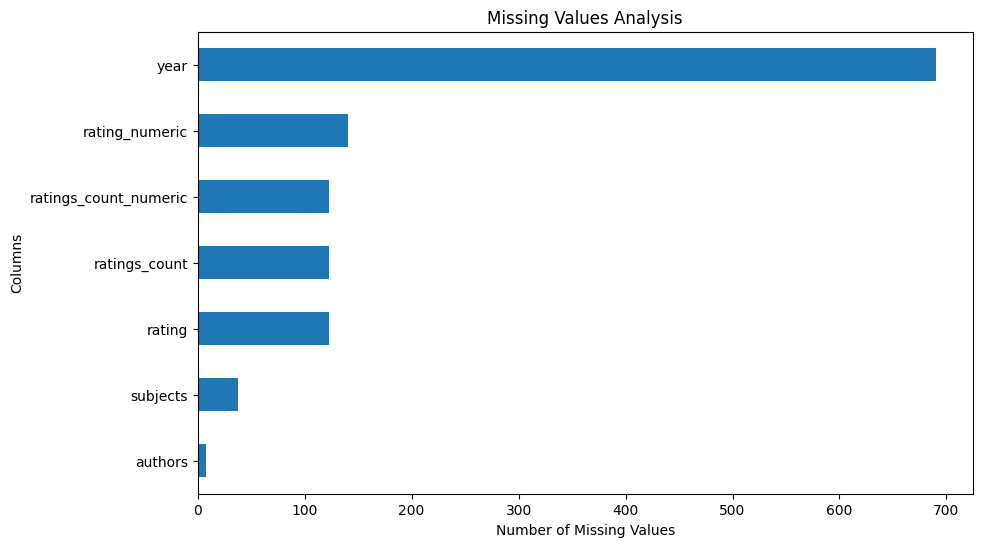

In [26]:
missing_values = final_df.replace("", pd.NA).isna().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10,6))
missing_values.sort_values().plot(kind="barh")

plt.title("Missing Values Analysis")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.show()

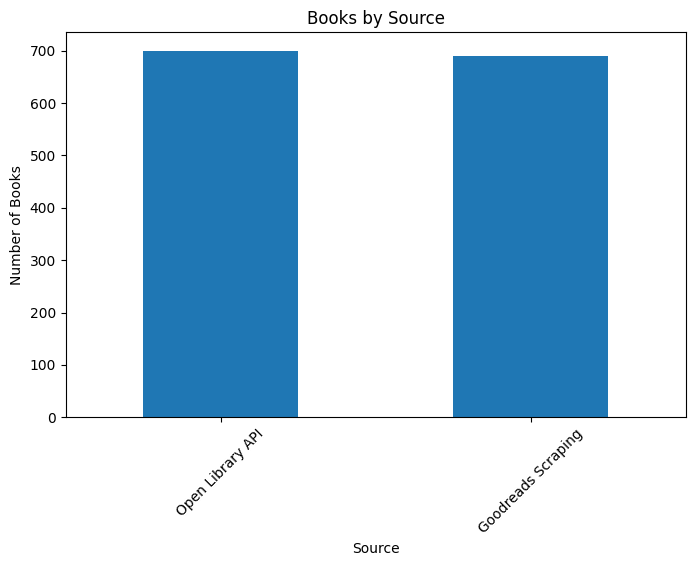

In [27]:
#EDA : Books by Source

plt.figure(figsize=(8,5))

final_df["source"].value_counts().plot(kind="bar")

plt.title("Books by Source")
plt.xlabel("Source")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.show()

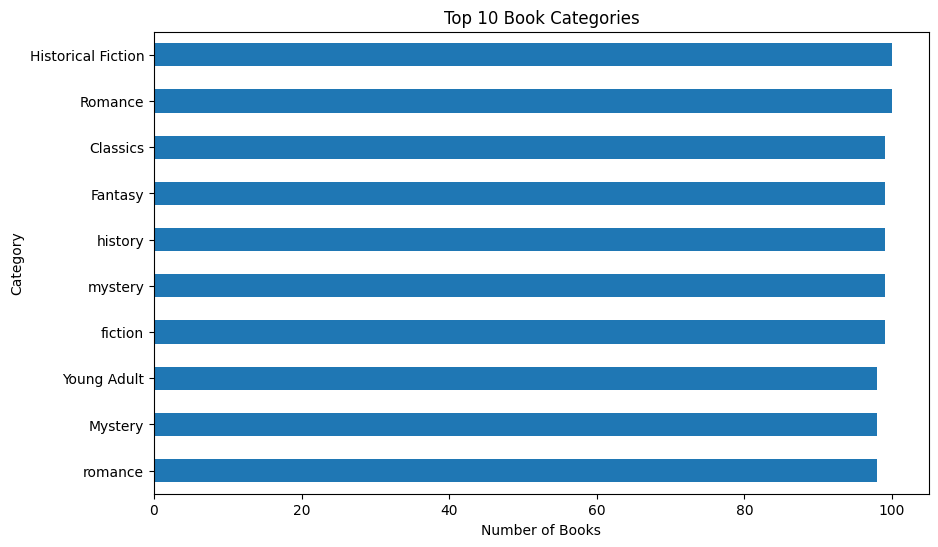

In [28]:
#EDA: Top Categories

top_categories = (
    final_df["category"]
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 10 Book Categories")
plt.xlabel("Number of Books")
plt.ylabel("Category")
plt.show()

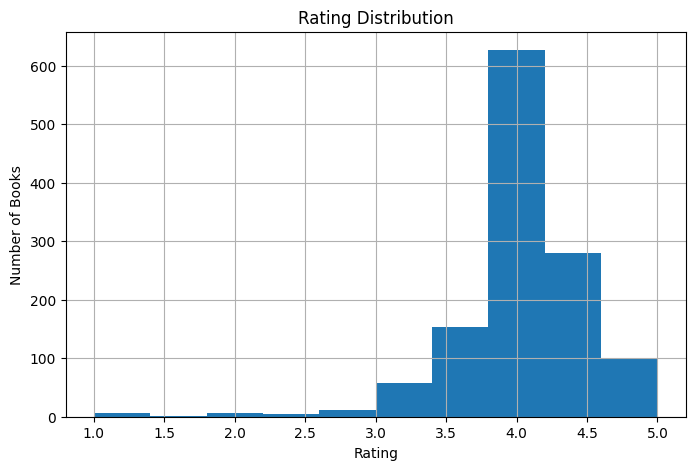

In [29]:
#EDA  Rating Distribution

rating_data = final_df["rating_numeric"].dropna()

plt.figure(figsize=(8,5))

rating_data.hist(bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

<Figure size 1000x600 with 0 Axes>

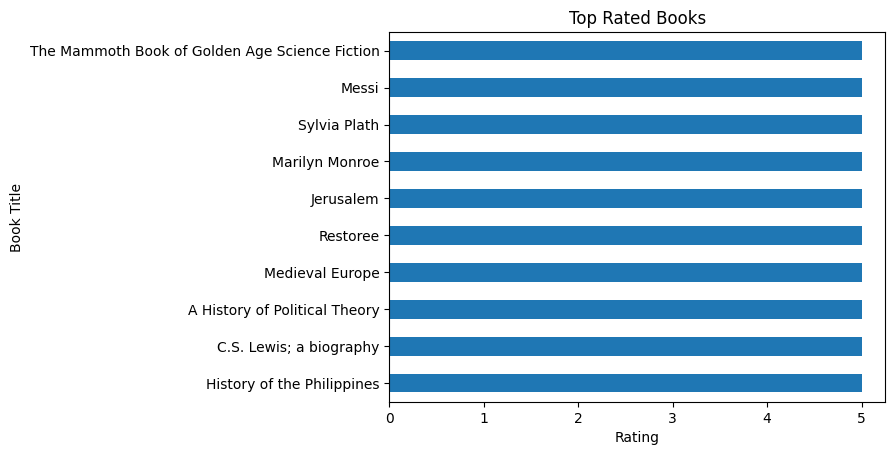

In [30]:
#Top Rated Books

top_rated = (
    final_df.dropna(subset=["rating_numeric"])
    .sort_values("rating_numeric", ascending=False)
    [["title", "authors", "category", "rating_numeric"]]
    .head(10)
)

top_rated

plt.figure(figsize=(10,6))

top_rated.sort_values("rating_numeric").plot(
    x="title",
    y="rating_numeric",
    kind="barh",
    legend=False
)

plt.title("Top Rated Books")
plt.xlabel("Rating")
plt.ylabel("Book Title")
plt.show()

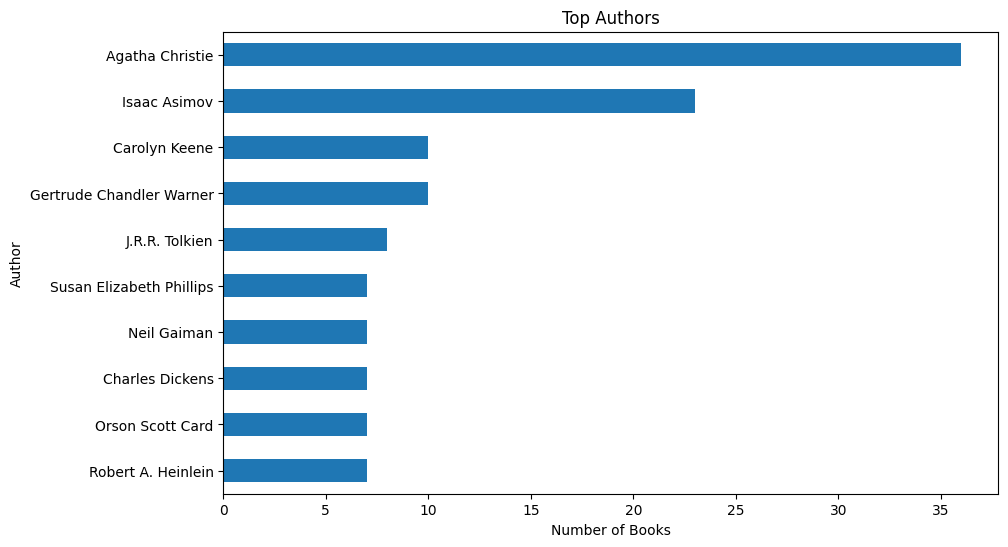

In [31]:
#EDA: Top Authors

top_authors = (
    final_df["authors"]
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_authors.sort_values().plot(kind="barh")

plt.title("Top Authors")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.show()

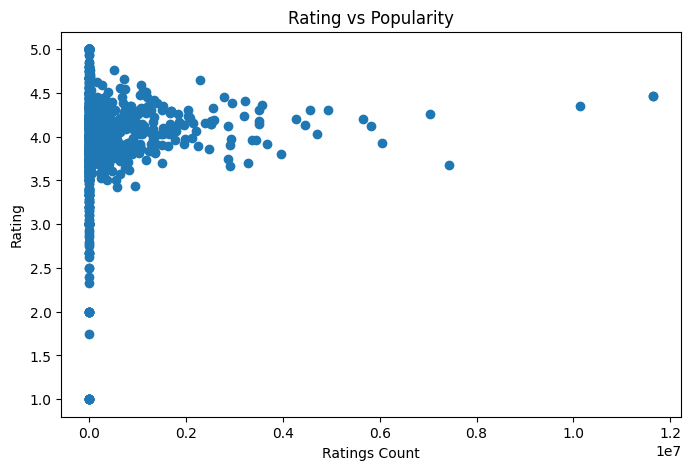

In [33]:
#EDA : Rating vs Popularity

plot_df = final_df.dropna(
    subset=["rating_numeric", "ratings_count_numeric"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df["ratings_count_numeric"],
    plot_df["rating_numeric"]
)

plt.title("Rating vs Popularity")
plt.xlabel("Ratings Count")
plt.ylabel("Rating")
plt.show()



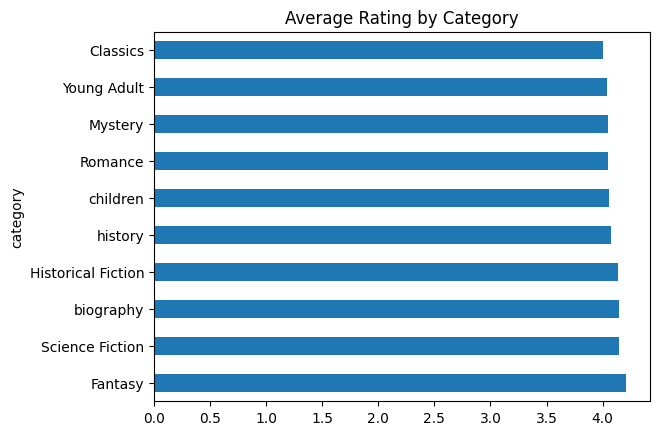

In [34]:
#Category vs Average Rating

category_rating = (
    final_df.groupby("category")
    ["rating_numeric"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

category_rating.plot(
    kind="barh"
)

plt.title(
    "Average Rating by Category"
)

plt.show()